### Multiple Linear Regression

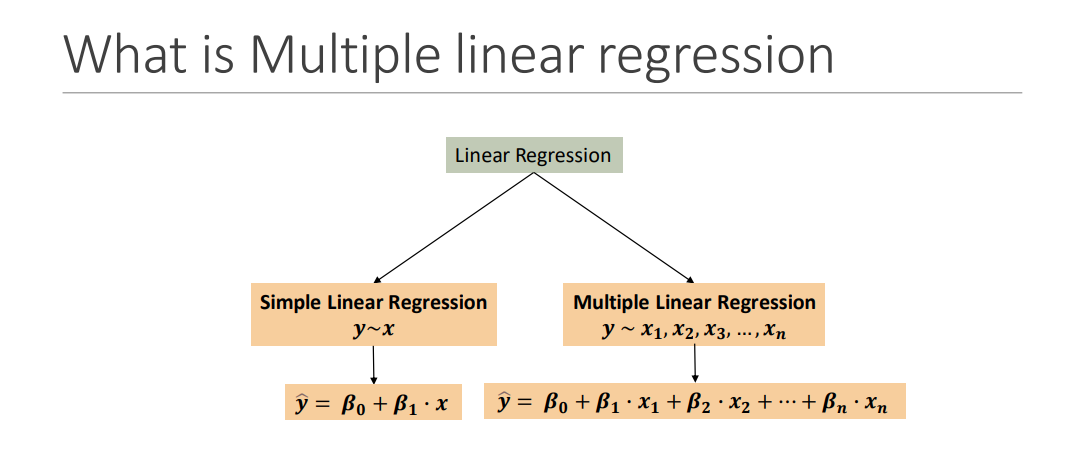

In [31]:
from warnings import filterwarnings
filterwarnings("ignore")

### Step 1: Data Ingestion(Reading csv file)

In [32]:
import numpy as np
import pandas as pd
df = pd.read_csv("50_Startups.csv")
df.head()

,RND,ADMIN,MKT,STATE,PROFIT
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


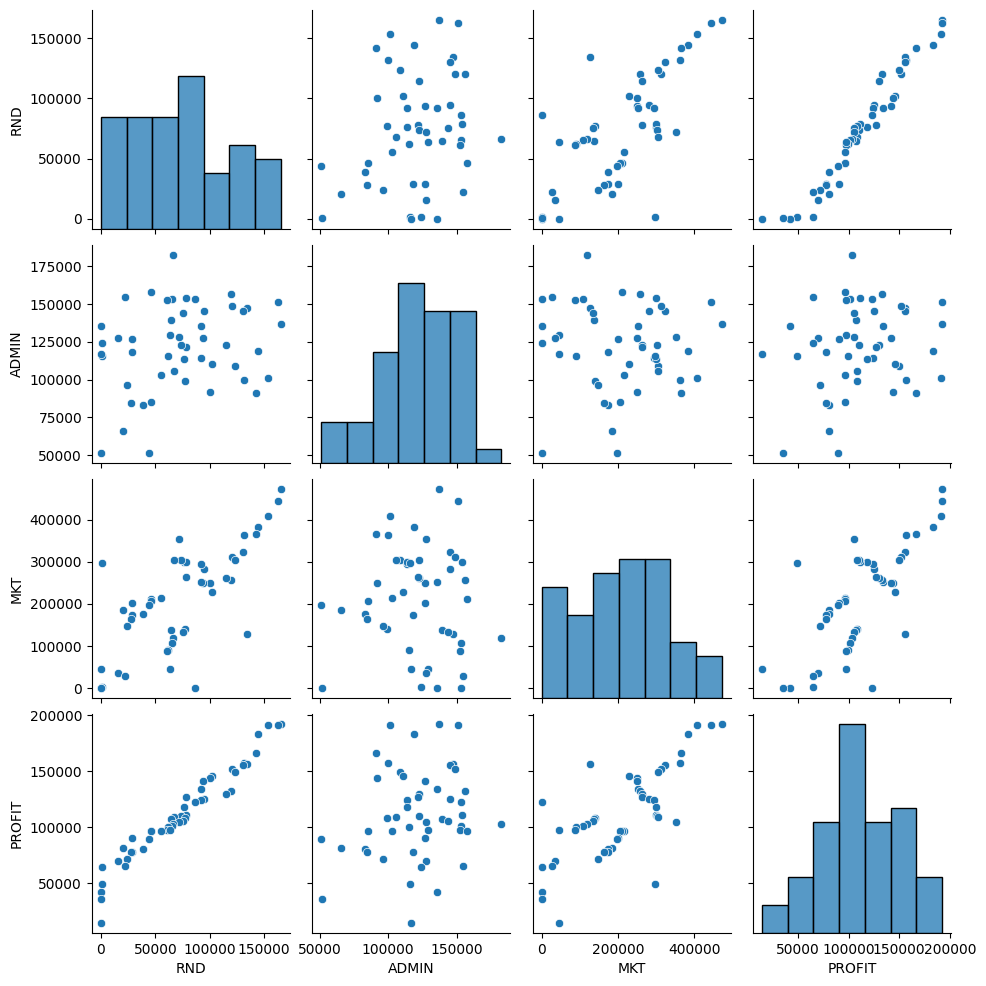

In [33]:
import seaborn as sns
sns.pairplot(data = df)

### Step 2: Perform Basic Data Quality Checks

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RND     50 non-null     float64
 1   ADMIN   50 non-null     float64
 2   MKT     50 non-null     float64
 3   STATE   50 non-null     object 
 4   PROFIT  50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [35]:
df.isna().sum()

RND       0
ADMIN     0
MKT       0
STATE     0
PROFIT    0
dtype: int64

In [36]:
df.duplicated().sum()

0

### Step 3: Separate X and Y(PROFIT)
1. PROFIT ~ RND, ADMIN, MKT
2. PROFIT_pred = B0 + B1xRND + B2xADMIN + B3xMKT
3. Update Line

In [37]:
X = df[["RND", "ADMIN", "MKT"]]
Y = df[["PROFIT"]]

In [38]:
X.head()

,RND,ADMIN,MKT
0,165349.20,136897.80,471784.10
1,162597.70,151377.59,443898.53
2,153441.51,101145.55,407934.54
3,144372.41,118671.85,383199.62
4,142107.34,91391.77,366168.42


In [39]:
Y.head()

,PROFIT
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94


### Step 4: Build the Model

In [40]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, Y)

LinearRegression()

In [41]:
model.intercept_

array([50122.19298987])

In [42]:
model.coef_

array([[ 0.80571505, -0.02681597,  0.02722806]])

In [43]:
X.columns

Index(['RND', 'ADMIN', 'MKT'], dtype='object')

### PROFIT_pred = 50122.19 + 0.8057xRND - 0.9268xADMIN + 0.0272xMKT
1. If RND increases by 1 unit profit will increase by 0.8057 units
2. If ADMIN increase by 1 unit profit will decrease by 0.0268 units
3. If MKT increase by 1 units profit will increase by 0.0272 units

### Step 5: Model Evaluation

In [44]:
model.score(X, Y)

0.9507459940683246

In [45]:
from sklearn.metrics import(
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

In [46]:
def evaluate_model(model, x, y):
    # predict the result using the model
    ypred = model.predict(x)

    # Calculate all metrics
    mse = mean_squared_error(y, ypred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, ypred)
    mape = mean_absolute_percentage_error(y, ypred)
    r2 = r2_score(y, ypred)
    

    # Print all above terms
    print(f"MSE:{mse:.2f}")
    print(f"RMSE:{rmse:.2f}")
    print(f"MAE:{mae:.2f}")
    print(f"MAPE:{mape:.2%}")
    print(f"R2:{r2:.2%}")

In [47]:
X.head()

,RND,ADMIN,MKT
0,165349.20,136897.80,471784.10
1,162597.70,151377.59,443898.53
2,153441.51,101145.55,407934.54
3,144372.41,118671.85,383199.62
4,142107.34,91391.77,366168.42


In [48]:
Y.head()

,PROFIT
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94


In [49]:
evaluate_model(model, X, Y)

MSE:78417126.02
RMSE:8855.34
MAE:6471.45
MAPE:10.60%
R2:95.07%


In [50]:
ypred = model.predict(X)
ypred[0:5]

array([[192521.25289008],
       [189156.76823227],
       [182147.2790962 ],
       [173696.70002553],
       [172139.51418327]])

In [51]:
Y.head()

,PROFIT
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94


### Step 6: Out of Sample Prediction

In [52]:
X.values[0:5]

array([[165349.2 , 136897.8 , 471784.1 ],
       [162597.7 , 151377.59, 443898.53],
       [153441.51, 101145.55, 407934.54],
       [144372.41, 118671.85, 383199.62],
       [142107.34,  91391.77, 366168.42]])

In [53]:
X.columns

Index(['RND', 'ADMIN', 'MKT'], dtype='object')

In [54]:
rnd = 1_20_000
admin = 80_000
mkt = 95_000
xnew = [[rnd, admin, mkt]]
pred = model.predict(xnew)
pred

array([[147249.38766425]])

### PROFIT_pred = 50122.19 + 0.8057xRND - 0.0268xADMIN + 0.0272xMKT

In [55]:
50122.19 + 0.8057*1_60_000 - 0.0268*80_000 + 0.0272*95_000

179474.19